# 05 — Estudo de ablação com retreinamento

**O notebook `05_ablacao` é um estudo de ablação com retreinamento (Retraining-Based Ablation Study), e não apenas uma análise de perturbação.** Cada configuração de features, incluindo o modelo original de referência, é treinada novamente do zero, com reajuste do pré-processamento, dos classificadores base e do meta-modelo, mantendo os mesmos dados, hiperparâmetros e protocolo de validação.


| Experimento | Features |
|---|---|
| Modelo original | Título + Notícia + Autor |
| Sem autoria | Título + Notícia |
| Somente notícia | Notícia |
| Sem título | Notícia + Autor |

As quatro versões são retreinadas do zero, inclusive a referência original. Mantêm os registros, a ordem, os hiperparâmetros e as cinco dobras externas/internas da V2. O TF-IDF e o one-hot são ajustados dentro de cada base e dobra. As variantes sem autor excluem o transformer de autoria; as variantes sem título vetorizam apenas Notícia.

O esquema de entrada continua aceitando as três colunas por compatibilidade, mas somente as features indicadas entram nos classificadores. Não há nova seleção de hiperparâmetros ou limiar. Os artefatos do modelo original são preservados.

Execute as células em ordem. O retreinamento de quatro stackings com validação aninhada pode levar bastante tempo. O notebook não contém resultados calculados antecipadamente.


In [1]:
from pathlib import Path
import sys
import json
import platform
import warnings
from time import perf_counter
from typing import Any, cast
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, roc_auc_score

for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    module_dir = base / "notebooks/v2_validacao_externa"
    if (module_dir / "pipeline_utils.py").is_file():
        sys.path.insert(0, str(module_dir))
        break
else:
    raise FileNotFoundError("Execute dentro do projeto.")
from pipeline_utils import (project_root, load_bundle, load_manifest, read_partition,
                            sha256_file, validate_labels, normalize_text, prepare_authors,
                            FEATURE_COLUMNS, MODEL_RELATIVE)
from ablation_utils import EXPERIMENTOS, construir_variante
ROOT = project_root()
DATA_DIR = ROOT / "notebooks/v2_validacao_externa/data/processed/texto_autor_exploratorio_v4"
REPORT_DIR = ROOT / "reports/v2_stacking_texto_autor_exploratorio/ablacao"
MODEL_DIR = ROOT / "models/v2_stacking_texto_autor_exploratorio/ablacao"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
SEED, N_SPLITS = 42, 5
bundle = load_bundle(ROOT / MODEL_RELATIVE)
original = cast(Pipeline, bundle["pipeline"])
hash_original = sha256_file(ROOT / MODEL_RELATIVE)
manifest = load_manifest(DATA_DIR)
if manifest != bundle["manifest"]:
    raise ValueError("O modelo e as partições não pertencem à mesma execução.")
for nome, esperado in manifest["files"].items():
    if sha256_file(DATA_DIR / nome) != esperado:
        raise ValueError(f"Partição alterada: {nome}")
if sha256_file(ROOT / "data/FakeRecogna.xlsx") != manifest["raw_sha256"]:
    raise ValueError("Dataset original alterado após o pré-processamento.")
train = read_partition(DATA_DIR / "train.csv").reset_index(drop=True)
y_train = validate_labels(train["label"]).to_numpy(dtype=int)
X_train = train.loc[:, FEATURE_COLUMNS].copy()
stack = cast(StackingClassifier, original.named_steps["clf"])
params_stack = stack.get_params(deep=False)
cv_interno = params_stack["cv"]
if not isinstance(cv_interno, StratifiedKFold):
    raise ValueError("Esperado StratifiedKFold interno.")
config_cv_interno = vars(cv_interno)
if cv_interno.get_n_splits() != 5 or not config_cv_interno["shuffle"] or config_cv_interno["random_state"] != SEED or params_stack["passthrough"]:
    raise ValueError("O artefato diverge do protocolo do notebook 02.")
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
divisoes = list(cv.split(X_train, y_train))
dobras = np.full(len(train), -1, dtype=int)
for dobra, (idx_fit, idx_val) in enumerate(divisoes, 1):
    if np.bincount(y_train[idx_fit], minlength=2).min() < N_SPLITS:
        raise ValueError("Classe insuficiente para as dobras internas.")
    dobras[idx_val] = dobra
mapa = pd.read_csv(ROOT / "reports/v2_stacking_texto_autor_exploratorio/mapa_dobras_cv.csv")
if mapa["id_original"].duplicated().any() or set(mapa["id_original"]) != set(train["id_original"]):
    raise ValueError("Mapa de dobras não cobre exatamente o treino.")
if not np.array_equal(mapa.set_index("id_original").loc[train["id_original"], "dobra_validacao"].to_numpy(), dobras):
    raise ValueError("Dobras diferentes das usadas no notebook 02.")
display(pd.DataFrame([{"experimento": k, "nome": v[0], "features": " + ".join(v[1])} for k, v in EXPERIMENTOS.items()]))


,experimento,nome,features
0,original,Modelo original,Titulo + Noticia + Autor
1,sem_autoria,Sem autoria,Titulo + Noticia
2,somente_noticia,Somente notícia,Noticia
3,sem_titulo,Sem título,Noticia + Autor


## Retreinamento e validação OOF

Nenhuma informação do holdout ou conjunto externo participa dos ajustes abaixo. Cada variante usa exatamente os mesmos índices de validação. Também são exportados os deltas pareados por dobra; o desvio entre cinco dobras não é um intervalo de confiança.

**Experimento	Features**

Modelo original	Título + Notícia + Autor
Sem autoria	Título + Notícia
Somente notícia	Notícia
Sem título	Notícia + Autor

In [2]:
def medir(y: np.ndarray, previsto: np.ndarray, escore: np.ndarray) -> dict[str, Any]:
    cm = confusion_matrix(y, previsto, labels=[0, 1])
    return {"n": len(y), "f1_macro": float(f1_score(y, previsto, labels=[0, 1], average="macro", zero_division=0)),
            "accuracy": float(accuracy_score(y, previsto)), "balanced_accuracy": float(balanced_accuracy_score(y, previsto)),
            "recall_fake": float(cm[0, 0] / cm[0].sum()) if cm[0].sum() else None,
            "recall_real": float(cm[1, 1] / cm[1].sum()) if cm[1].sum() else None,
            "roc_auc_real": float(roc_auc_score(y, escore)) if np.unique(y).size == 2 else None,
            "fake_como_real": int(cm[0, 1]), "real_como_fake": int(cm[1, 0])}

registros_metricas: list[dict[str, Any]] = []
registros_dobras: list[dict[str, Any]] = []
modelos: dict[str, Pipeline] = {}
for experimento in EXPERIMENTOS:
    pasta = REPORT_DIR / experimento
    pasta.mkdir(parents=True, exist_ok=True)
    variante = construir_variante(original, experimento)
    pred_oof = np.full(len(train), -1, dtype=int)
    escore_oof = np.full(len(train), np.nan)
    visitas = np.zeros(len(train), dtype=int)
    with warnings.catch_warnings():
        warnings.simplefilter("error", ConvergenceWarning)
        for dobra, (idx_fit, idx_val) in enumerate(divisoes, 1):
            modelo_dobra = cast(Pipeline, clone(variante))
            inicio = perf_counter()
            modelo_dobra.fit(X_train.iloc[idx_fit], y_train[idx_fit])
            tempo = perf_counter() - inicio
            previsto = np.asarray(modelo_dobra.predict(X_train.iloc[idx_val]), dtype=int)
            escore = np.asarray(modelo_dobra.decision_function(X_train.iloc[idx_val]), dtype=float).ravel()
            pred_oof[idx_val], escore_oof[idx_val] = previsto, escore
            visitas[idx_val] += 1
            registros_dobras.append({"experimento": experimento, "dobra": dobra,
                                      "ajuste_segundos": tempo, **medir(y_train[idx_val], previsto, escore)})
            print(f"{experimento}: dobra {dobra}/5 concluída", flush=True)
        if not np.all(visitas == 1) or (pred_oof < 0).any() or not np.isfinite(escore_oof).all():
            raise RuntimeError("Cobertura OOF inválida.")
        registros_metricas.append({"experimento": experimento, "avaliacao": "oof", **medir(y_train, pred_oof, escore_oof)})
        tabela_oof = train[["id_original", "label"]].copy()
        tabela_oof["dobra"] = dobras
        tabela_oof["predito"] = pred_oof
        tabela_oof["escore_real"] = escore_oof
        tabela_oof.to_csv(pasta / "predicoes_oof.csv", index=False)
        inicio = perf_counter()
        variante.fit(X_train, y_train)
        tempo_final = perf_counter() - inicio
    modelos[experimento] = variante
    artefato = {"pipeline": variante, "experimento": experimento, "features_ativas": EXPERIMENTOS[experimento][1],
                "manifest": manifest, "referencia_sha256": hash_original, "sklearn_version": sklearn.__version__,
                "ajuste_final_segundos": tempo_final}
    destino = MODEL_DIR / f"{experimento}.joblib"
    joblib.dump(artefato, destino)
    recarregado = cast(Pipeline, joblib.load(destino)["pipeline"])
    if not np.array_equal(variante.predict(X_train.iloc[:5]), recarregado.predict(X_train.iloc[:5])):
        raise RuntimeError("Predições divergentes após serialização.")
    pd.DataFrame(registros_dobras).to_csv(REPORT_DIR / "metricas_por_dobra.csv", index=False)
    pd.DataFrame(registros_metricas).to_csv(REPORT_DIR / "comparacao_metricas.csv", index=False)
    print(f"{experimento}: ajuste final e artefato concluídos", flush=True)


original: dobra 1/5 concluída
original: dobra 2/5 concluída
original: dobra 3/5 concluída
original: dobra 4/5 concluída
original: dobra 5/5 concluída
original: ajuste final e artefato concluídos
sem_autoria: dobra 1/5 concluída
sem_autoria: dobra 2/5 concluída
sem_autoria: dobra 3/5 concluída
sem_autoria: dobra 4/5 concluída
sem_autoria: dobra 5/5 concluída
sem_autoria: ajuste final e artefato concluídos
somente_noticia: dobra 1/5 concluída
somente_noticia: dobra 2/5 concluída
somente_noticia: dobra 3/5 concluída
somente_noticia: dobra 4/5 concluída
somente_noticia: dobra 5/5 concluída
somente_noticia: ajuste final e artefato concluídos
sem_titulo: dobra 1/5 concluída
sem_titulo: dobra 2/5 concluída
sem_titulo: dobra 3/5 concluída
sem_titulo: dobra 4/5 concluída
sem_titulo: dobra 5/5 concluída
sem_titulo: ajuste final e artefato concluídos


## Avaliação dos modelos congelados

Usa o mesmo holdout e os mesmos IDs do subconjunto externo retido no notebook 03, sem novas exclusões por variante. O rótulo externo é conferido no CSV original (0 = Fake, 1 = Real). Todas as variantes já foram treinadas antes de avaliar esses conjuntos.

Holdout e externo já foram observados nos notebooks anteriores. Esta análise é exploratória e não deve escolher um novo campeão ou limiar. Melhora externa não certifica independência de eventos/fontes.


In [4]:
holdout = read_partition(DATA_DIR / "test_holdout.csv").reset_index(drop=True)
if not set(train["id_original"]).isdisjoint(holdout["id_original"]):
    raise ValueError("IDs compartilhados com holdout.")
if not set(train["texto"].map(normalize_text)).isdisjoint(holdout["texto"].map(normalize_text)):
    raise ValueError("Texto compartilhado com holdout.")
EXTERNAL_DIR = ROOT / "reports/v2_stacking_texto_autor_exploratorio/avaliacao/fakerecogna_extrativo"
resultado_externo = json.loads((EXTERNAL_DIR / "metricas.json").read_text(encoding="utf-8"))
EXTERNAL_PATH = ROOT / "data/fakerecogna_extrativo.csv"
if resultado_externo["data_sha256"] != sha256_file(EXTERNAL_PATH) or resultado_externo["model_sha256"] != hash_original:
    raise ValueError("A auditoria externa pertence a outro dataset ou modelo.")
externo = pd.read_csv(EXTERNAL_DIR / "predicoes.csv", keep_default_na=False)
raw_externo = pd.read_csv(EXTERNAL_PATH, keep_default_na=False)
ids_externos = pd.to_numeric(externo["id_externo"], errors="raise").to_numpy(dtype=float)
if not np.isfinite(ids_externos).all() or not np.equal(ids_externos, np.floor(ids_externos)).all():
    raise ValueError("IDs externos não inteiros.")
ids_externos = ids_externos.astype(int)
if externo["id_externo"].duplicated().any() or len(externo) != resultado_externo["n_avaliado"] or len(raw_externo) != resultado_externo["n_original"]:
    raise ValueError("Subconjunto externo alterado.")
if (ids_externos < 0).any() or (ids_externos >= len(raw_externo)).any():
    raise ValueError("ID externo fora do CSV original.")
referencia_externa = raw_externo.iloc[ids_externos].reset_index(drop=True)
for campo in FEATURE_COLUMNS:
    if not externo[campo].astype(str).reset_index(drop=True).equals(referencia_externa[campo].astype(str)):
        raise ValueError(f"Entrada externa diverge do CSV original: {campo}")
y_externo = validate_labels(pd.to_numeric(referencia_externa["Label"]).map({0: 1, 1: 0})).to_numpy(dtype=int)
if not np.array_equal(y_externo, validate_labels(externo["label"]).to_numpy(dtype=int)):
    raise ValueError("Rótulos externos divergentes.")
autores_treino = set(prepare_authors(train).ravel().tolist())
registros_autores: list[dict[str, Any]] = []
for avaliacao, frame, alvo, id_coluna in [
    ("holdout", holdout, validate_labels(holdout["label"]).to_numpy(dtype=int), "id_original"),
    ("externo_exploratorio", externo, y_externo, "id_externo"),
]:
    autores = prepare_authors(frame).ravel()
    grupos_autor = np.asarray(["ausente" if a == "autor_desconhecido" else "conhecido" if a in autores_treino else "inedito" for a in autores])
    for experimento, modelo in modelos.items():
        entrada = frame.loc[:, FEATURE_COLUMNS]
        previsto = np.asarray(modelo.predict(entrada), dtype=int)
        escore = np.asarray(modelo.decision_function(entrada), dtype=float).ravel()
        registros_metricas.append({"experimento": experimento, "avaliacao": avaliacao, **medir(alvo, previsto, escore)})
        predicoes = frame[[id_coluna, "label"]].copy()
        predicoes["predito"] = previsto
        predicoes["escore_real"] = escore
        predicoes["grupo_autor"] = grupos_autor
        predicoes.to_csv(REPORT_DIR / experimento / f"predicoes_{avaliacao}.csv", index=False)
        for grupo_autor in ["conhecido", "inedito", "ausente"]:
            mascara = grupos_autor == grupo_autor
            if mascara.any():
                registros_autores.append({"experimento": experimento, "avaliacao": avaliacao,
                                          "grupo_autor": grupo_autor, **medir(alvo[mascara], previsto[mascara], escore[mascara])})
comparacao = pd.DataFrame(registros_metricas)
comparacao.to_csv(REPORT_DIR / "comparacao_metricas.csv", index=False)
pd.DataFrame(registros_autores).to_csv(REPORT_DIR / "metricas_por_autor_conhecido.csv", index=False)
if sha256_file(ROOT / MODEL_RELATIVE) != hash_original:
    raise RuntimeError("O modelo original foi alterado durante a ablação.")
display(comparacao)


,experimento,avaliacao,n,f1_macro,accuracy,balanced_accuracy,recall_fake,recall_real,roc_auc_real,fake_como_real,real_como_fake
0,original,oof,9518,0.990019,0.990019,0.990016,0.988005,0.992027,0.998721,57,38
1,sem_autoria,oof,9518,0.976255,0.976256,0.976253,0.974327,0.978179,0.995174,122,104
2,somente_noticia,oof,9518,0.950095,0.950095,0.950095,0.950547,0.949643,0.986143,235,240
3,sem_titulo,oof,9518,0.988233,0.988233,0.988230,0.986111,0.990348,0.998426,66,46
4,original,holdout,2384,0.993289,0.993289,0.993303,0.990826,0.995781,0.998957,11,5
5,sem_autoria,holdout,2384,0.977768,0.977768,0.977775,0.976647,0.978903,0.996844,28,25
6,somente_noticia,holdout,2384,0.953859,0.953859,0.953882,0.949958,0.957806,0.989336,60,50
7,sem_titulo,holdout,2384,0.991191,0.991191,0.991198,0.989992,0.992405,0.998830,12,9
8,original,externo_exploratorio,46229,0.767536,0.787147,0.769086,0.539014,0.999158,0.987251,9819,21
9,sem_autoria,externo_exploratorio,46229,0.843664,0.851284,0.839124,0.684225,0.994023,0.979544,6726,149


## Comparação pareada e interpretação

O efeito da autoria é comparado em dois contextos: original − sem autoria (com título) e sem título − somente notícia (sem título). Os deltas são calculados sobre os mesmos registros. Ganhos internos acompanhados de perdas externas, especialmente para autores inéditos, são compatíveis com dependência de autoria, mas não demonstram causalidade. Examine suporte por classe, erros e estabilidade entre dobras.


,avaliacao,contexto,metrica,delta_com_menos_sem_autor
0,oof,com_titulo,f1_macro,0.013764
1,oof,com_titulo,balanced_accuracy,0.013763
2,oof,com_titulo,recall_fake,0.013678
3,oof,com_titulo,recall_real,0.013848
4,oof,sem_titulo,f1_macro,0.038138
5,oof,sem_titulo,balanced_accuracy,0.038134
6,oof,sem_titulo,recall_fake,0.035564
7,oof,sem_titulo,recall_real,0.040705
8,holdout,com_titulo,f1_macro,0.015521
9,holdout,com_titulo,balanced_accuracy,0.015528


experimento,original,sem_autoria,sem_titulo,somente_noticia,delta_autoria_com_titulo,delta_autoria_sem_titulo
dobra,,,,,,
1,0.990546,0.980567,0.987920,0.956932,0.009979,0.030987
2,0.988971,0.974789,0.987920,0.940124,0.014181,0.047796
3,0.988445,0.971639,0.987395,0.946953,0.016807,0.040441
4,0.994220,0.980557,0.992643,0.953229,0.013663,0.039414
5,0.987914,0.973725,0.985286,0.953230,0.014189,0.032056


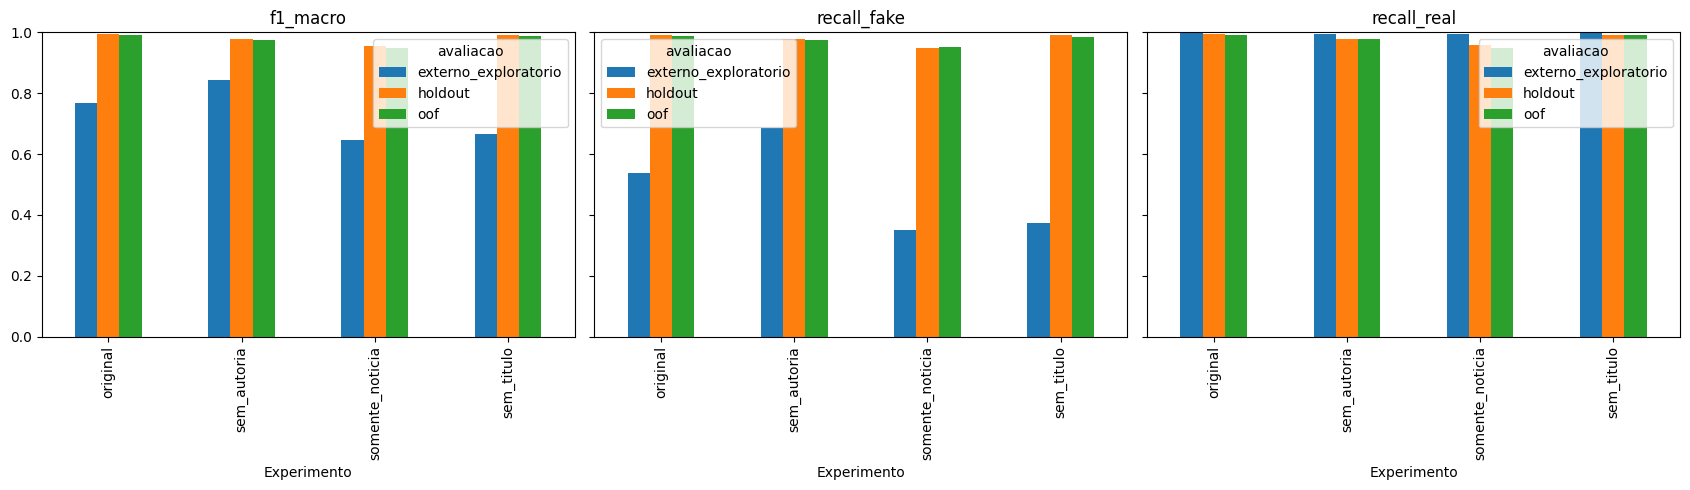

Relatórios: C:\Users\LAISA\OneDrive\Documentos\identificador-de-fake-news\reports\v2_stacking_texto_autor_exploratorio\ablacao
Modelos retreinados: C:\Users\LAISA\OneDrive\Documentos\identificador-de-fake-news\models\v2_stacking_texto_autor_exploratorio\ablacao


In [5]:
registros_deltas: list[dict[str, Any]] = []
for avaliacao in comparacao["avaliacao"].unique():
    tabela = comparacao.loc[comparacao["avaliacao"].eq(avaliacao)].set_index("experimento")
    for com_autor, sem_autor, contexto in [("original", "sem_autoria", "com_titulo"), ("sem_titulo", "somente_noticia", "sem_titulo")]:
        for metrica in ["f1_macro", "balanced_accuracy", "recall_fake", "recall_real"]:
            delta = float(str(tabela.at[com_autor, metrica])) - float(str(tabela.at[sem_autor, metrica]))
            registros_deltas.append({"avaliacao": avaliacao, "contexto": contexto, "metrica": metrica, "delta_com_menos_sem_autor": delta})
deltas_autoria = pd.DataFrame(registros_deltas)
deltas_autoria.to_csv(REPORT_DIR / "deltas_autoria.csv", index=False)
metricas_dobras = pd.DataFrame(registros_dobras)
pareadas = metricas_dobras.pivot(index="dobra", columns="experimento", values="f1_macro")
pareadas["delta_autoria_com_titulo"] = pareadas["original"] - pareadas["sem_autoria"]
pareadas["delta_autoria_sem_titulo"] = pareadas["sem_titulo"] - pareadas["somente_noticia"]
pareadas.to_csv(REPORT_DIR / "deltas_pareados_por_dobra.csv")
display(deltas_autoria)
display(pareadas)
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, metrica in zip(np.asarray(axes).ravel(), ["f1_macro", "recall_fake", "recall_real"]):
    comparacao.pivot(index="experimento", columns="avaliacao", values=metrica).reindex(list(EXPERIMENTOS)).plot.bar(ax=ax)
    ax.set_title(metrica)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Experimento")
fig.tight_layout()
fig.savefig(REPORT_DIR / "comparacao_ablacao.png", dpi=160, bbox_inches="tight")
fig.savefig(REPORT_DIR / "comparacao_ablacao.svg", bbox_inches="tight")
plt.show()
plt.close(fig)
protocolo = {"seed": SEED, "dobras_externas": 5, "dobras_internas": 5,
             "experimentos": EXPERIMENTOS, "manifest": manifest, "modelo_original_sha256": hash_original,
             "dataset_externo_sha256": sha256_file(EXTERNAL_PATH), "python": platform.python_version(),
             "sklearn": sklearn.__version__, "pandas": pd.__version__, "numpy": np.__version__,
             "avaliacao_externa": "exploratoria_em_subconjunto_previamente_observado",
             "hiperparametros_referencia": original.get_params(deep=True)}
(REPORT_DIR / "protocolo.json").write_text(json.dumps(protocolo, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
texto = "# Ablação com retreinamento\n\n"
texto += "Quatro variantes retreinadas nas mesmas cinco dobras externas/internas e partições da V2.\n\n"
texto += "## Métricas\n\n" + comparacao.to_csv(index=False) + "\n"
texto += "## Efeito descritivo da autoria (com − sem)\n\n" + deltas_autoria.to_csv(index=False) + "\n"
texto += "Consulte metricas_por_autor_conhecido.csv e deltas_pareados_por_dobra.csv. "
texto += "O desvio entre dobras não é intervalo de confiança. As divisões podem compartilhar fontes/eventos. "
texto += "O externo e holdout já foram observados; não se escolheu modelo ou limiar. "
texto += "Confirmar generalização exige outro teste independente e, quando possível, divisão por fonte/evento/período.\n"
(REPORT_DIR / "interpretacao.md").write_text(texto, encoding="utf-8")
print("Relatórios:", REPORT_DIR)
print("Modelos retreinados:", MODEL_DIR)


In [6]:
# Conclusao gerada a partir das metricas efetivamente calculadas.
from IPython.display import Markdown
metricas_conclusao = pd.read_csv(REPORT_DIR / "comparacao_metricas.csv")
nomes_features = {
    "original": "Título + Notícia + Autor",
    "sem_autoria": "Título + Notícia (sem autoria)",
    "somente_noticia": "Somente Notícia",
    "sem_titulo": "Notícia + Autor (sem título)",
}
partes_conclusao = ["## Conclusão da ablação com retreinamento\n"]
for tipo, descricao in [("oof", "validação OOF interna"), ("holdout", "holdout interno"),
                        ("externo_exploratorio", "avaliação externa exploratória")]:
    ranking = metricas_conclusao.loc[metricas_conclusao["avaliacao"].eq(tipo)].sort_values("f1_macro", ascending=False)
    if len(ranking) != 4:
        raise ValueError(f"Avaliacao incompleta: {tipo}")
    melhor = ranking.iloc[0].to_dict()
    empatados = ranking.loc[ranking["f1_macro"].eq(melhor["f1_macro"]), "experimento"].tolist()
    nomes = " / ".join(nomes_features[str(chave)] for chave in empatados)
    resultado = "houve empate no maior F1-macro entre" if len(empatados) > 1 else "o maior F1-macro foi obtido por"
    partes_conclusao.append(
        f"Na **{descricao}**, {resultado} **{nomes}**, com **F1-macro de {float(melhor['f1_macro']):.4f}**, "
        f"acurácia de {100 * float(melhor['accuracy']):.2f}%, recall Fake de {100 * float(melhor['recall_fake']):.2f}% "
        f"e recall Real de {100 * float(melhor['recall_real']):.2f}%.\n")
externo_conclusao = metricas_conclusao.loc[metricas_conclusao["avaliacao"].eq("externo_exploratorio")].set_index("experimento")
completo = externo_conclusao.loc["original"].to_dict()
sem_autor = externo_conclusao.loc["sem_autoria"].to_dict()
delta_f1 = float(sem_autor["f1_macro"]) - float(completo["f1_macro"])
delta_recall = 100 * (float(sem_autor["recall_fake"]) - float(completo["recall_fake"]))
reducao_erros = int(completo["fake_como_real"]) - int(sem_autor["fake_como_real"])
partes_conclusao.append(
    f"Comparando **Título + Notícia** com **Título + Notícia + Autor** no externo, "
    f"o delta de F1-macro ao retirar autoria foi **{delta_f1:+.4f}**, e o delta de recall Fake foi "
    f"**{delta_recall:+.2f} pontos percentuais**. Os erros Fake como Real passaram de "
    f"**{int(completo['fake_como_real']):,}** para **{int(sem_autor['fake_como_real']):,}**, "
    f"uma redução de **{reducao_erros:,}** erros (valor negativo indica aumento).\n")
if delta_f1 > 0:
    partes_conclusao.append("**Neste conjunto externo, retirar a autoria melhorou o F1-macro.** "
        "O ganho interno da autoria acompanhado de pior desempenho externo é compatível com dependência de "
        "padrões de autores/fontes do desenvolvimento; essa comparação não demonstra a causa da diferença.\n")
elif delta_f1 < 0:
    partes_conclusao.append("**Neste conjunto externo, manter a autoria melhorou o F1-macro** quando título e notícia estavam presentes.\n")
else:
    partes_conclusao.append("Retirar a autoria não alterou o F1-macro externo na comparação com título e notícia.\n")
partes_conclusao.append("A melhor variante é descrita pelo **F1-macro**, com recalls e erros apresentados para avaliar a troca entre classes. "
    "A comparação se refere aos quatro stackings retreinados e ao subconjunto externo observado. "
    "Não foi testada a combinação Título + Autor sem Notícia. "
    "Como holdout e externo já foram observados, o resultado é exploratório: não comprova superioridade universal "
    "nem independência de fontes/eventos e não substitui automaticamente o modelo original. "
    "A confirmação exige outro teste independente.\n")
conclusao_ablacao = "\n".join(partes_conclusao)
display(Markdown(conclusao_ablacao))
(REPORT_DIR / "conclusao_ablacao.md").write_text(conclusao_ablacao, encoding="utf-8")
interpretacao_path = REPORT_DIR / "interpretacao.md"
texto_anterior = interpretacao_path.read_text(encoding="utf-8") if interpretacao_path.exists() else ""
texto_anterior = texto_anterior.split("## Conclusão da ablação com retreinamento")[0].rstrip()
interpretacao_path.write_text(texto_anterior + "\n\n" + conclusao_ablacao, encoding="utf-8")


## Conclusão da ablação com retreinamento

Na **validação OOF interna**, o maior F1-macro foi obtido por **Título + Notícia + Autor**, com **F1-macro de 0.9900**, acurácia de 99.00%, recall Fake de 98.80% e recall Real de 99.20%.

Na **holdout interno**, o maior F1-macro foi obtido por **Título + Notícia + Autor**, com **F1-macro de 0.9933**, acurácia de 99.33%, recall Fake de 99.08% e recall Real de 99.58%.

Na **avaliação externa exploratória**, o maior F1-macro foi obtido por **Título + Notícia (sem autoria)**, com **F1-macro de 0.8437**, acurácia de 85.13%, recall Fake de 68.42% e recall Real de 99.40%.

Comparando **Título + Notícia** com **Título + Notícia + Autor** no externo, o delta de F1-macro ao retirar autoria foi **+0.0761**, e o delta de recall Fake foi **+14.52 pontos percentuais**. Os erros Fake como Real passaram de **9,819** para **6,726**, uma redução de **3,093** erros (valor negativo indica aumento).

**Neste conjunto externo, retirar a autoria melhorou o F1-macro.** O ganho interno da autoria acompanhado de pior desempenho externo é compatível com dependência de padrões de autores/fontes do desenvolvimento; essa comparação não demonstra a causa da diferença.

A melhor variante é descrita pelo **F1-macro**, com recalls e erros apresentados para avaliar a troca entre classes. A comparação se refere aos quatro stackings retreinados e ao subconjunto externo observado. Não foi testada a combinação Título + Autor sem Notícia. Como holdout e externo já foram observados, o resultado é exploratório: não comprova superioridade universal nem independência de fontes/eventos e não substitui automaticamente o modelo original. A confirmação exige outro teste independente.


5580